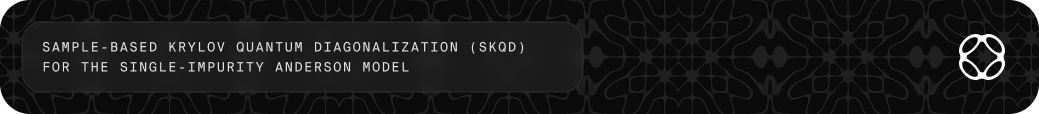

We estimate the ground-state energy of a **40-qubit one-dimensional single-impurity Anderson model (SIAM)** using SKQD — a hybrid algorithm that builds a Krylov subspace via quantum time evolution and diagonalises it with classical sample-based postprocessing. Haiqu's circuit compression cuts gate count by **98%**, yielding **3.4× lower energy error** with **2.9× fewer determinants** and **~5× faster classical postprocessing** versus Baseline uncompressed Qiskit circuits. Reference: [Yu et al., *arXiv* 2501.09702 (2025)](https://arxiv.org/abs/2501.09702).

**Workflow overview**

- **1. Initialize & Configure** — Set up the Haiqu SDK, define SIAM Hamiltonian parameters.
- **2. Preprocess** — Build Krylov time-evolution circuits and compress them.
- **3. Execute** — Run compressed and original circuits on quantum hardware via `haiqu.run()`.
- **4. Retrieve & Postprocess** — Apply sample-based quantum diagonalization via `haiqu.postprocess_skqd()`.
- **5. Analyze & Conclude** — Compare scenarios, generate Pareto plots, quantify advantages.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the notebook

Import the necessary libraries, set the run mode and credentials, initialise the Haiqu SDK, and load the target device.

> Note: this notebook requires `ffsim` package to be installed. Make sure that you have run `pip install -r requirements.txt` or `pip install haiqu-sdk[skqd]` before attempting to run this notebook. Also note that this package may not work correctly on Windows systems.

In [ ]:
import json
from haiqu.sdk import haiqu
from haiqu.sdk.schemas import SKQDResult
from haiqu.sdk.skqd import (
    siam_hamiltonian, get_orbital_rotation, rotate_basis,
    SKQDOptions, build_siam_momentum_basis_krylov_circuits,
)
from utils.skqd_utils import (
    load_json_data, plot_quality_and_determinants, plot_pareto_quality_vs_time,
)

# ── Configuration ───────────────────────────────────────────
RUN_ON_DEVICE = False        # set True to actually submit and retrieve
DEVICE_ID = "ibm_fez"        # or "fake_marrakesh" for a free local simulator
OPTIONS = {                  # set to {} when using a fake device
    "ibm_quantum_token":    "YOUR_IBM_QUANTUM_TOKEN",
    "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE",
}
NUM_ORBITALS = 20            # spatial orbitals (1 impurity + 19 bath); qubits = 2 × NUM_ORBITALS
KRYLOV_DIM = 10

haiqu.login()
haiqu.init("SKQD - SIAM Model")

device = haiqu.get_device(DEVICE_ID)

## The model & method

The one-dimensional single-impurity Anderson model couples a magnetic impurity to a non-interacting bath chain:

$$H = -t \sum_{\langle i,j \rangle \in \text{bath},\,\sigma} (c^\dagger_{i\sigma} c_{j\sigma} + \text{h.c.}) \;-\; V \sum_\sigma (c^\dagger_{d\sigma} c_{1\sigma} + \text{h.c.}) \;+\; \mu\, n_d \;+\; U\, n_{d\uparrow} n_{d\downarrow}$$

with bath hopping $t$, impurity-bath hybridisation $V$, chemical potential $\mu$, and on-site Coulomb $U$. SKQD generates a Krylov subspace by quantum time evolution, $\mathcal{K} = \text{span}\{|\psi_0\rangle, e^{-iH\Delta t}|\psi_0\rangle, e^{-2iH\Delta t}|\psi_0\rangle, \ldots\}$, then samples the resulting states on hardware. Classical Sample-based Quantum Diagonalization (SQD) filters those samples to valid electron configurations, builds a compact Hamiltonian, and diagonalises to estimate the ground-state energy. Haiqu's compression makes the Krylov circuits shallow enough to produce high-overlap samples on noisy hardware.

In [2]:
# SIAM Hamiltonian parameters
U = 10.0             # on-site Coulomb at the impurity
t = 1.0              # bath hopping
V = 1.0              # impurity-bath hybridisation
mu = -0.5 * U        # half-filling chemical potential
TIME_STEP = 0.2
SHOTS = 1000

n_bath = NUM_ORBITALS - 1
nelec = (NUM_ORBITALS // 2, NUM_ORBITALS // 2)

# Build SIAM Hamiltonian and rotate to momentum basis (sparser ground state for SQD)
h1e_site, h2e_site = siam_hamiltonian(norb=NUM_ORBITALS, t=t, U=U, V=V, mu=mu)
orbital_rotation = get_orbital_rotation(NUM_ORBITALS)
h1e, h2e = rotate_basis(h1e_site, h2e_site, orbital_rotation.T.conj())
impurity_index = n_bath // 2

# Krylov time-evolution circuits
circuits = build_siam_momentum_basis_krylov_circuits(
    NUM_ORBITALS, KRYLOV_DIM, TIME_STEP,
    h1e=h1e, h2e=h2e, impurity_index=impurity_index,
)
print(f"Built {len(circuits)} Krylov circuits ({circuits[0].num_qubits} qubits each)")

Built 10 Krylov circuits (40 qubits each)


In [3]:
# Compress (Haiqu's key feature) — typically ~98% gate reduction
compression_jobs = [haiqu.state_compression(c, fine_tuning="heavy") for c in circuits]
compressed_circuits = [j.result() for j in compression_jobs]
avg_quality = sum(j.quality for j in compression_jobs) / len(compression_jobs)
print(f"Compressed {len(compressed_circuits)} circuits — average quality {avg_quality:.4f}")

# Transpile both sets for the target device
transpiled_original   = haiqu.transpile(circuits,            device=device, optimization_level=3)
transpiled_compressed = haiqu.transpile(compressed_circuits, device=device, optimization_level=3)

Compressed 10 circuits — average quality 0.9394


## Submit jobs to the QPU

We submit two batches: the **Original** (uncompressed Qiskit) circuits and the **Compressed** (Haiqu) circuits. Each batch is a single `haiqu.run()` call that takes the full list of Krylov circuits at once. The job IDs are saved to disk so we can pick up the results later in a new session. Set `RUN_ON_DEVICE = True` to execute on real hardware (requires IBM Quantum credentials); otherwise the notebook will load cached measurement counts from a previous run further down.

In [4]:
JOB_IDS_FILE = "saved_job_ids.json"

if RUN_ON_DEVICE:
    job_original = haiqu.run(
        transpiled_original, shots=SHOTS, device=device, options=OPTIONS,
    )
    job_compressed = haiqu.run(
        transpiled_compressed, shots=SHOTS, device=device, options=OPTIONS,
    )
    saved_job_ids = {"original": job_original.id, "compressed": job_compressed.id}
    with open(JOB_IDS_FILE, "w") as f:
        json.dump(saved_job_ids, f)
    print(f"Submitted: {saved_job_ids}")
    print(f"Job IDs saved to {JOB_IDS_FILE}")
else:
    print("Skipping live submission — cached results will be loaded next.")

Skipping live submission — cached results will be loaded next.


## Retrieve hardware results

For live runs, we load the saved job IDs and call `haiqu.get_job(job_id).result()` to pull the measurement counts for all Krylov circuits — this works in a fresh notebook session too, so you can submit, walk away, then come back later. For the cached path we read the JSON files saved from a previous run.

In [5]:
if RUN_ON_DEVICE:
    with open(JOB_IDS_FILE) as f:
        saved_job_ids = json.load(f)
    original_results   = haiqu.get_job(saved_job_ids["original"]).result()
    compressed_results = haiqu.get_job(saved_job_ids["compressed"]).result()
else:
    with open("run_results_original.json") as f:
        original_results = json.load(f)
    with open("run_results_compressed.json") as f:
        compressed_results = json.load(f)

print(f"Original:   {len(original_results)} circuit results")
print(f"Compressed: {len(compressed_results)} circuit results")

Original:   10 circuit results
Compressed: 10 circuit results


## Postprocess with SQD

Measurement counts go through Sample-based Quantum Diagonalization: filter to valid electron configurations, sample batches, build a Hamiltonian subspace, diagonalise, and iterate until the energy converges. `haiqu.postprocess_skqd()` dispatches this CPU-intensive job to a background worker; we save the postprocessing job IDs to disk and call `.result()` when we're ready. For the cached path we load the `SKQDResult` JSON files directly.

In [6]:
SKQD_OPTIONS = SKQDOptions(
    symmetrize_spin=True, max_iterations=10,
    num_batches=3, samples_per_batch=100,
    configuration_recovery=True,
)
POSTPROCESS_IDS_FILE = "saved_postprocess_ids.json"

if RUN_ON_DEVICE:
    job_original = haiqu.postprocess_skqd(
        results=original_results, num_shots=SHOTS,
        h1e=h1e, h2e=h2e, norb=NUM_ORBITALS, nelec=nelec,
        skqd_options=SKQD_OPTIONS,
    )
    job_compressed = haiqu.postprocess_skqd(
        results=compressed_results, num_shots=SHOTS,
        h1e=h1e, h2e=h2e, norb=NUM_ORBITALS, nelec=nelec,
        skqd_options=SKQD_OPTIONS,
    )
    saved_postprocess_ids = {"original": job_original.id, "compressed": job_compressed.id}
    with open(POSTPROCESS_IDS_FILE, "w") as f:
        json.dump(saved_postprocess_ids, f)
    print(f"Submitted SKQD jobs: {saved_postprocess_ids}")

    # Block until SKQD finishes (large systems can take 10+ min)
    original_skqd   = haiqu.get_job(saved_postprocess_ids["original"]).result()
    compressed_skqd = haiqu.get_job(saved_postprocess_ids["compressed"]).result()
else:
    original_skqd   = SKQDResult.load_from_json("postprocess_result_original.json")
    compressed_skqd = SKQDResult.load_from_json("postprocess_result_compressed.json")

# Reference values for comparison (DMRG ground truth and IBM tutorial baseline)
ref = load_json_data("reference_data.json")
dmrg_energy         = ref["dmrg_energy"]
ibm_tutorial_energy = ref["ibm_tutorial_energy"]
ibm_num_determinant = ref["ibm_num_determinant"]

> 💡 **Key Result:** Compressed circuits achieve **3.4× lower energy error** with **2.9× fewer determinants** compared to uncompressed Qiskit circuits. Haiqu's compression reduces hardware noise, producing measurement samples with higher ground-state overlap. This reduces the SQD subspace dimension from 81,225 to 27,556 determinants, yielding both higher accuracy and lower computational cost. Both scenarios are compared against the DMRG classical reference and the published IBM tutorial result.

"Logged object to the experiment 'SKQD - SIAM Model'. View on Dashboard: https://dashboard.haiqu.ai/experiment/exp-c4787da9-caf0-4e84-be82-88764db32629"

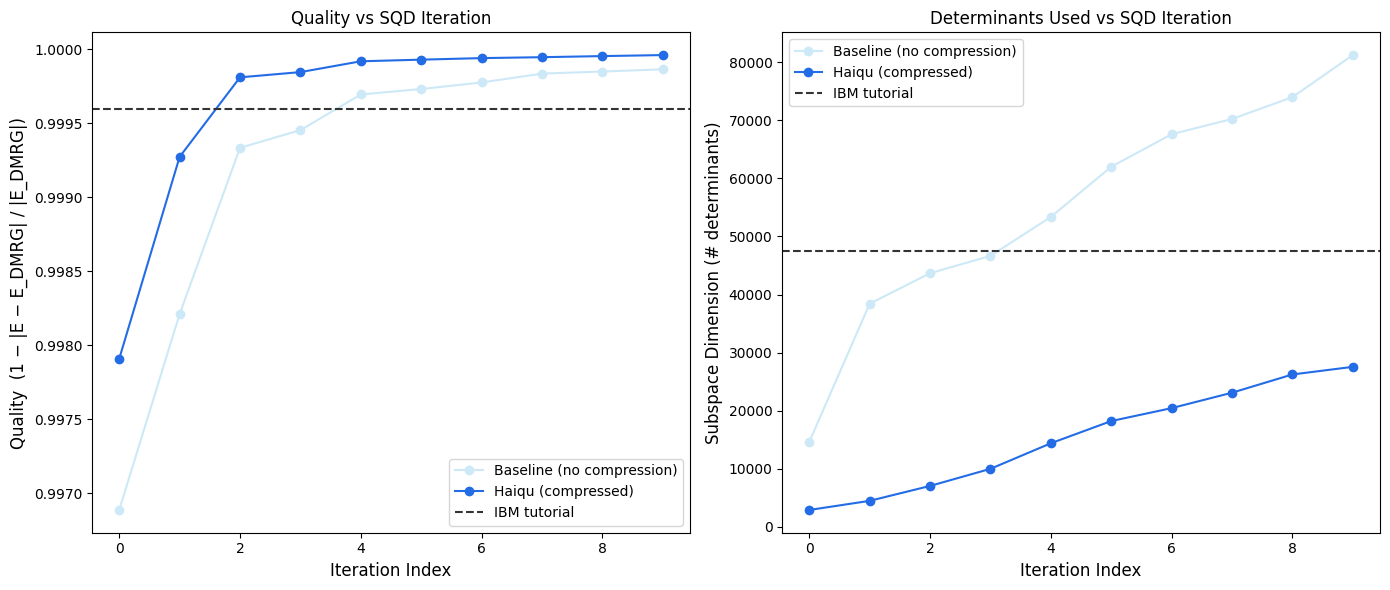

In [7]:
haiqu.log(
    plot_quality_and_determinants(
        haiqu_result=compressed_skqd,
        qiskit_result=original_skqd,
        dmrg_energy=dmrg_energy,
        ibm_tutorial_energy=ibm_tutorial_energy,
        ibm_num_determinant=ibm_num_determinant,
    ),
    name="quality_and_determinants",
)

"Logged object to the experiment 'SKQD - SIAM Model'. View on Dashboard: https://dashboard.haiqu.ai/experiment/exp-c4787da9-caf0-4e84-be82-88764db32629"

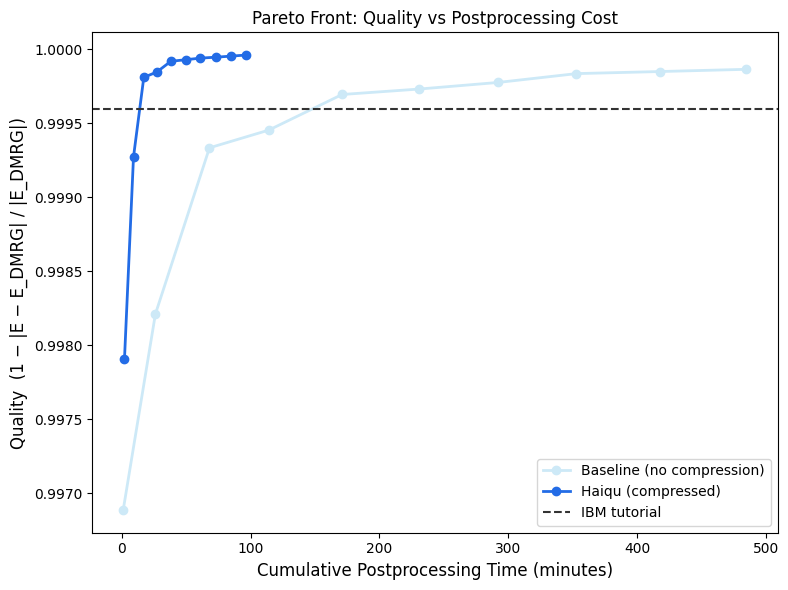

In [8]:
haiqu.log(
    plot_pareto_quality_vs_time(
        haiqu_result=compressed_skqd,
        qiskit_result=original_skqd,
        dmrg_energy=dmrg_energy,
        ibm_tutorial_energy=ibm_tutorial_energy,
    ),
    name="pareto_quality_vs_time",
)

## Conclusion

This notebook benchmarked Haiqu's circuit compression against uncompressed Qiskit transpilation in a Sample-based Krylov Quantum Diagonalization workflow on a **40-qubit single-impurity Anderson model** — a fermionic lattice problem beyond the reach of brute-force classical methods.

**Key findings:**

| Metric | Qiskit (uncompressed) | Haiqu (compressed) | Improvement |
|---|---|---|---|
| Energy error (vs DMRG) | 0.00389 Ha | 0.00113 Ha | **3.4× lower** |
| SQD subspace dimension | 81,225 | 27,556 | **2.9× fewer determinants** |
| Postprocessing time | ~485 min | ~96 min | **~5× faster** |
| Gate count | baseline | −98% | **98× reduction** |

Haiqu's compression reduces hardware noise, producing measurement samples with higher ground-state overlap. Smaller subspace dimensions then make the SQD diagonalisation both more accurate and faster.

**References:** Yu et al., "Quantum-Centric Algorithm for Sample-Based Krylov Diagonalization," *arXiv* 2501.09702 (2025); IBM Quantum tutorial: Sample-based Krylov quantum diagonalization of a fermionic lattice model.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

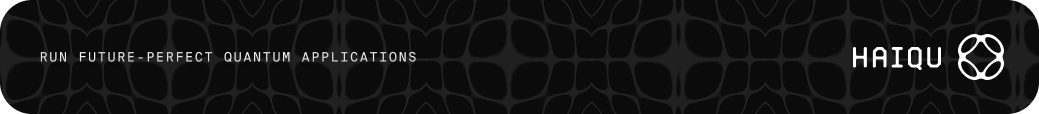